In [82]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [83]:
# Import dataset
data = pd.read_csv('Bengaluru_House_Data_052608.csv')
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [84]:
data.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [85]:
data.shape

(13320, 9)

In [86]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [87]:
data.shape

(13320, 9)

In [88]:
# show NaN values
data.isnull().sum()


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [89]:
data.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2117,), dtype=object)

In [90]:
data.bath.unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9., nan,  8.,  7., 11., 10., 14.,
       27., 12., 16., 40., 15., 13., 18.])

In [91]:
# Create a BHK column by extarcting from size column
data['BHK'] = data['size'].apply(lambda x: int(x.split(' ')[0]) if isinstance(x, str) else None)
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,BHK
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,2.0


In [92]:
data_1 = data.copy()
data_1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,BHK
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,2.0


In [93]:
data_1.BHK.unique()

array([ 2.,  4.,  3.,  6.,  1.,  8.,  7.,  5., 11.,  9., nan, 27., 10.,
       19., 16., 43., 14., 12., 13., 18.])

In [94]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
 9   BHK           13304 non-null  float64
dtypes: float64(4), object(6)
memory usage: 1.0+ MB


In [95]:
data_1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,BHK
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,2.0


In [96]:
data_1.shape

(13320, 10)

In [97]:
data_1.describe()

,bath,balcony,price,BHK
count,13247.000000,12711.000000,13320.000000,13304.000000
mean,2.692610,1.584376,112.565627,2.803743
std,1.341458,0.817263,148.971674,1.294974
min,1.000000,0.000000,8.000000,1.000000
25%,2.000000,1.000000,50.000000,2.000000
50%,2.000000,2.000000,72.000000,3.000000
75%,3.000000,2.000000,120.000000,3.000000
max,40.000000,3.000000,3600.000000,43.000000


<Axes: xlabel='total_sqft'>

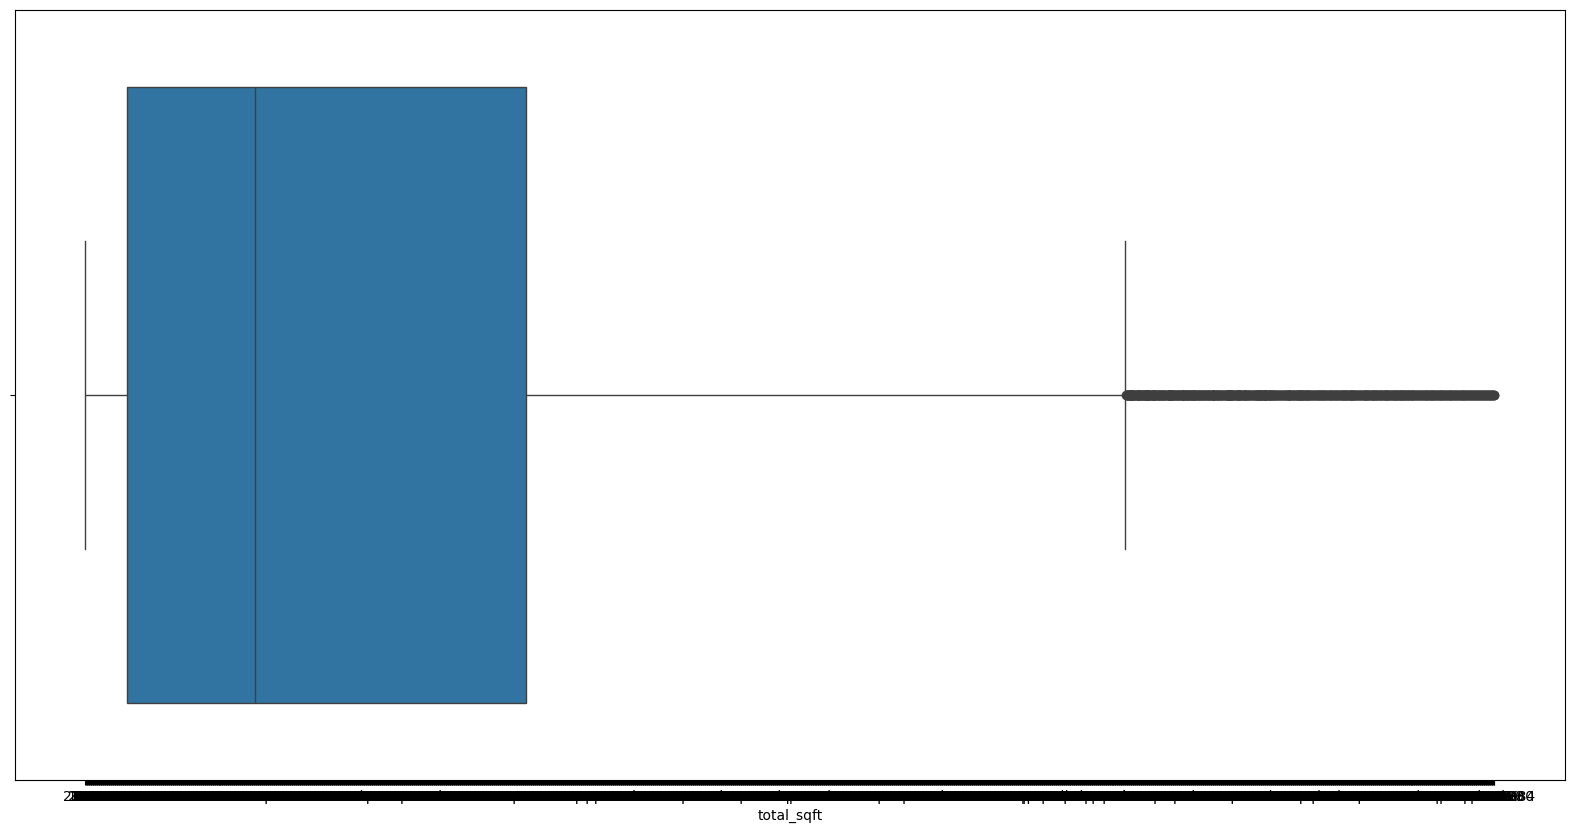

In [98]:
sns.boxplot(x=data_1['total_sqft'])

In [99]:
# List the area_type column
data_1['area_type'].value_counts()

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [100]:
# How many times did 'Defence Colony' appear in the 'location' column
(data_1['location'] == 'Defence Colony').sum()


np.int64(7)

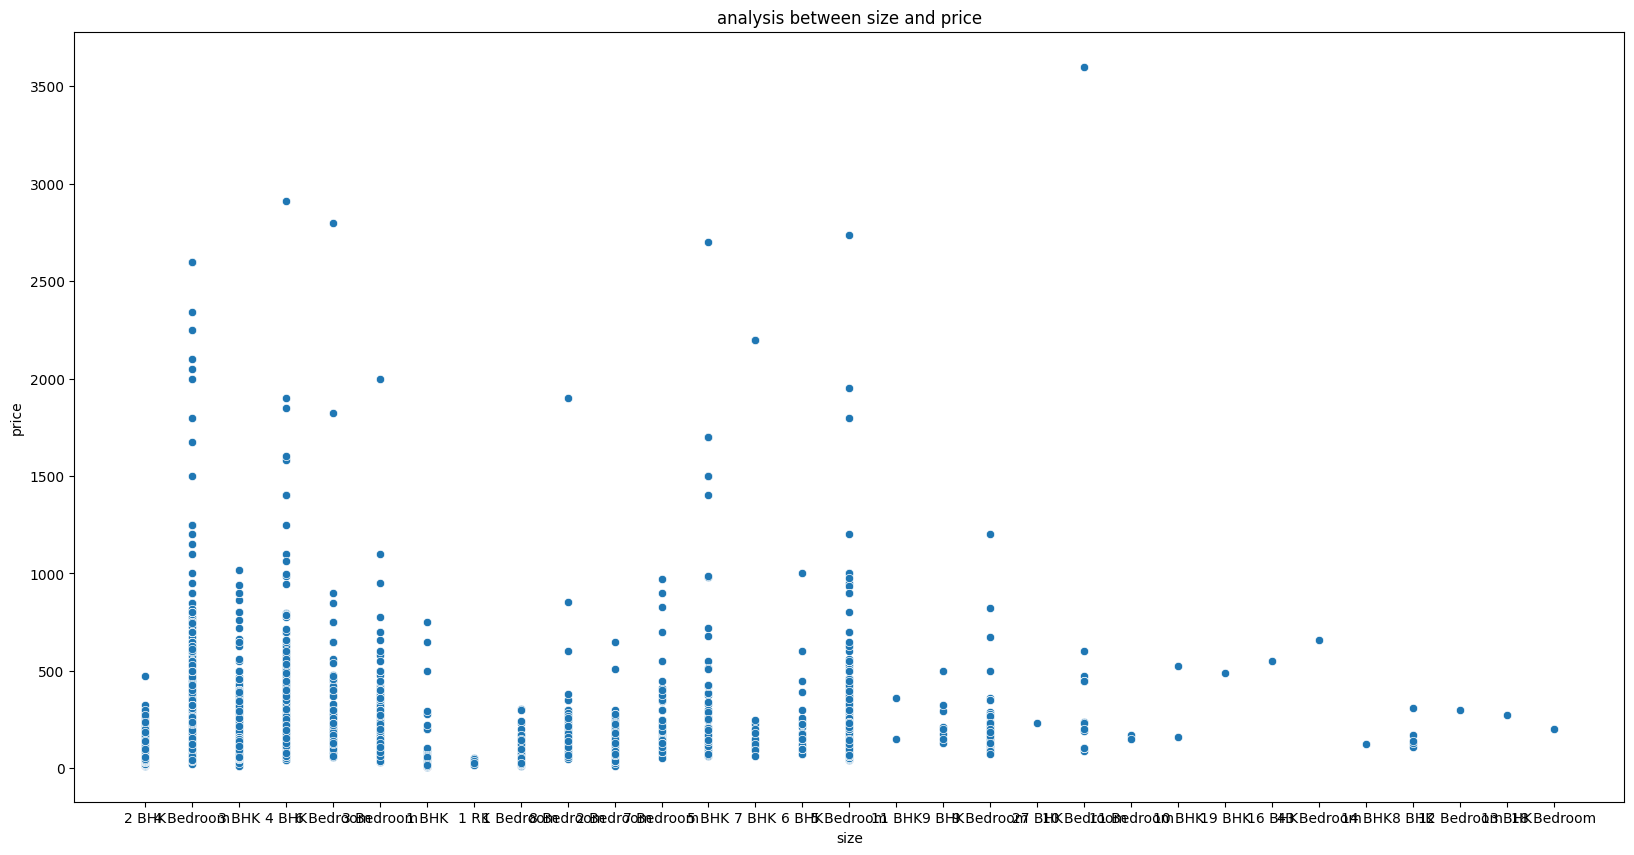

In [101]:
# Plotting a bivaraite analysis between 'size' and 'price'
sns.scatterplot(x='size', y='price', data=data)
plt.title('analysis between size and price')
plt.xlabel('size')
plt.ylabel('price')
plt.show()

In [102]:
# list the names in the location column
data_1['location'].value_counts()

location
Whitefield                         540
Sarjapur  Road                     399
Electronic City                    302
Kanakpura Road                     273
Thanisandra                        234
                                  ... 
3rd Stage Raja Rajeshwari Nagar      1
Chuchangatta Colony                  1
Electronic City Phase 1,             1
Chikbasavanapura                     1
Abshot Layout                        1
Name: count, Length: 1305, dtype: int64

In [103]:
# price list for houses located in 'Whitefield' from ascending order to descending order
data_1[data_1['location'] == 'Whitefield'].sort_values(by='price', ascending=True)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,BHK
7843,Super built-up Area,20-Dec,Whitefield,1 BHK,Somns T,540 - 740,1.0,0.0,19.830,1.0
5174,Built-up Area,Ready To Move,Whitefield,1 BHK,SatraNa,810,1.0,0.0,21.000,1.0
5044,Super built-up Area,Ready To Move,Whitefield,1 BHK,Pranthi,650,1.0,1.0,25.000,1.0
6423,Plot Area,Immediate Possession,Whitefield,NaN,SRniaGa,2324,NaN,NaN,26.730,NaN
1686,Super built-up Area,21-Dec,Whitefield,1 BHK,SudenEd,660 - 670,NaN,NaN,28.585,1.0
...,...,...,...,...,...,...,...,...,...,...
9195,Super built-up Area,18-Mar,Whitefield,3 BHK,Asarqz,1496,2.0,1.0,718.000,3.0
4602,Plot Area,Ready To Move,Whitefield,4 Bedroom,Chllea,4356,5.0,1.0,850.000,4.0
8958,Built-up Area,Ready To Move,Whitefield,5 Bedroom,Chpana,7200,5.0,2.0,900.000,5.0
1678,Plot Area,Ready To Move,Whitefield,5 Bedroom,NaN,3250,5.0,3.0,900.000,5.0


In [104]:
data_1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,BHK
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,2.0


In [105]:
data_1.shape

(13320, 10)

In [106]:
data_1.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
BHK               16
dtype: int64

Drop unneccesary features 

In [107]:
# drop colums that have large numbers of missing values 'society', 'balcony', 'availability'
data_1 = data_1.drop(['society', 'balcony', 'availability'], axis=1)
data_1.shape

(13320, 7)

In [108]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   13320 non-null  object 
 1   location    13319 non-null  object 
 2   size        13304 non-null  object 
 3   total_sqft  13320 non-null  object 
 4   bath        13247 non-null  float64
 5   price       13320 non-null  float64
 6   BHK         13304 non-null  float64
dtypes: float64(3), object(4)
memory usage: 728.6+ KB


In [109]:
data_2 = data_1.copy()
data_2.head()

,area_type,location,size,total_sqft,bath,price,BHK
0,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4.0
2,Built-up Area,Uttarahalli,3 BHK,1440,2.0,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3.0
4,Super built-up Area,Kothanur,2 BHK,1200,2.0,51.00,2.0


In [110]:
data_2.isnull().sum()

area_type      0
location       1
size          16
total_sqft     0
bath          73
price          0
BHK           16
dtype: int64

In [111]:
data_2.shape

(13320, 7)

In [112]:
# Drop missing values in data_2
data_2 = data_2.dropna()
data_2.isnull().sum()

area_type     0
location      0
size          0
total_sqft    0
bath          0
price         0
BHK           0
dtype: int64

In [113]:
# show 'total_sqft' rows that are in range format
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True
data_2[~data_2['total_sqft'].apply(is_float)].head(10)

,area_type,location,size,total_sqft,bath,price,BHK
30,Super built-up Area,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4.0
122,Super built-up Area,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4.0
137,Super built-up Area,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2.0
165,Super built-up Area,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2.0
188,Super built-up Area,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2.0
410,Super built-up Area,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1.0
549,Super built-up Area,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2.0
648,Built-up Area,Arekere,9 Bedroom,4125Perch,9.0,265.000,9.0
661,Super built-up Area,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2.0
672,Built-up Area,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4.0


In [114]:
data_3 = data_2.copy()
data_3.shape

(13246, 7)

In [115]:
data_3.describe()

,bath,price,BHK
count,13246.000000,13246.000000,13246.000000
mean,2.692586,112.389392,2.801902
std,1.341506,149.076587,1.295758
min,1.000000,8.000000,1.000000
25%,2.000000,50.000000,2.000000
50%,2.000000,72.000000,3.000000
75%,3.000000,120.000000,3.000000
max,40.000000,3600.000000,43.000000


In [116]:
# Define a function in 'total_sqft' to convert 'total_sqft' to numberic values and handle the ranges to get their average
def convert_sqft_to_num(x):
    try:
        if '-' in x:
            tokens = x.split('-')
            if len(tokens) == 2:
                return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None
data_3['total_sqft'] = data_3['total_sqft'].apply(convert_sqft_to_num)

In [117]:
data_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   13246 non-null  object 
 1   location    13246 non-null  object 
 2   size        13246 non-null  object 
 3   total_sqft  13200 non-null  float64
 4   bath        13246 non-null  float64
 5   price       13246 non-null  float64
 6   BHK         13246 non-null  float64
dtypes: float64(4), object(3)
memory usage: 827.9+ KB


In [118]:
# list of names in the 'location' column
data_3['location'].value_counts()


location
Whitefield                         534
Sarjapur  Road                     392
Electronic City                    302
Kanakpura Road                     266
Thanisandra                        233
                                  ... 
KAMAKIYA                             1
Wheelers Road                        1
MM Layout                            1
Devarabeesana Halli                  1
beml layout, basaveshwara nagar      1
Name: count, Length: 1304, dtype: int64

In [119]:
data_3['area_type'].value_counts()

area_type
Super built-up  Area    8740
Built-up  Area          2410
Plot  Area              2009
Carpet  Area              87
Name: count, dtype: int64

In [120]:
(data['location'] == 'Defence Colony').sum()

np.int64(7)

In [121]:
# List price column from highest to lowest
data_3.sort_values(by='price', ascending=False)

,area_type,location,size,total_sqft,bath,price,BHK
13067,Plot Area,Defence Colony,10 Bedroom,7150.0,13.0,3600.0,10.0
11080,Super built-up Area,Ashok Nagar,4 BHK,8321.0,5.0,2912.0,4.0
13200,Plot Area,Defence Colony,6 Bedroom,8000.0,6.0,2800.0,6.0
11763,Plot Area,Sadashiva Nagar,5 Bedroom,9600.0,7.0,2736.0,5.0
3180,Super built-up Area,Shanthala Nagar,5 BHK,8321.0,5.0,2700.0,5.0
...,...,...,...,...,...,...,...
5410,Super built-up Area,Attibele,1 BHK,400.0,1.0,10.0,1.0
12579,Super built-up Area,Chandapura,1 BHK,410.0,1.0,10.0,1.0
11091,Built-up Area,Attibele,1 BHK,410.0,1.0,10.0,1.0
8594,Built-up Area,Chandapura,1 BHK,450.0,1.0,9.0,1.0


In [122]:
data_3.shape

(13246, 7)

In [123]:
data_3[data_3['location'] == 'Whitefield'].sort_values(by='price', ascending=True)

,area_type,location,size,total_sqft,bath,price,BHK
7843,Super built-up Area,Whitefield,1 BHK,640.0,1.0,19.83,1.0
5174,Built-up Area,Whitefield,1 BHK,810.0,1.0,21.00,1.0
5044,Super built-up Area,Whitefield,1 BHK,650.0,1.0,25.00,1.0
10559,Super built-up Area,Whitefield,1 BHK,524.0,1.0,29.00,1.0
5782,Super built-up Area,Whitefield,1 BHK,530.0,1.0,29.44,1.0
...,...,...,...,...,...,...,...
9195,Super built-up Area,Whitefield,3 BHK,1496.0,2.0,718.00,3.0
4602,Plot Area,Whitefield,4 Bedroom,4356.0,5.0,850.00,4.0
8958,Built-up Area,Whitefield,5 Bedroom,7200.0,5.0,900.00,5.0
1678,Plot Area,Whitefield,5 Bedroom,3250.0,5.0,900.00,5.0


In [124]:
import matplotlib.pyplot as plt

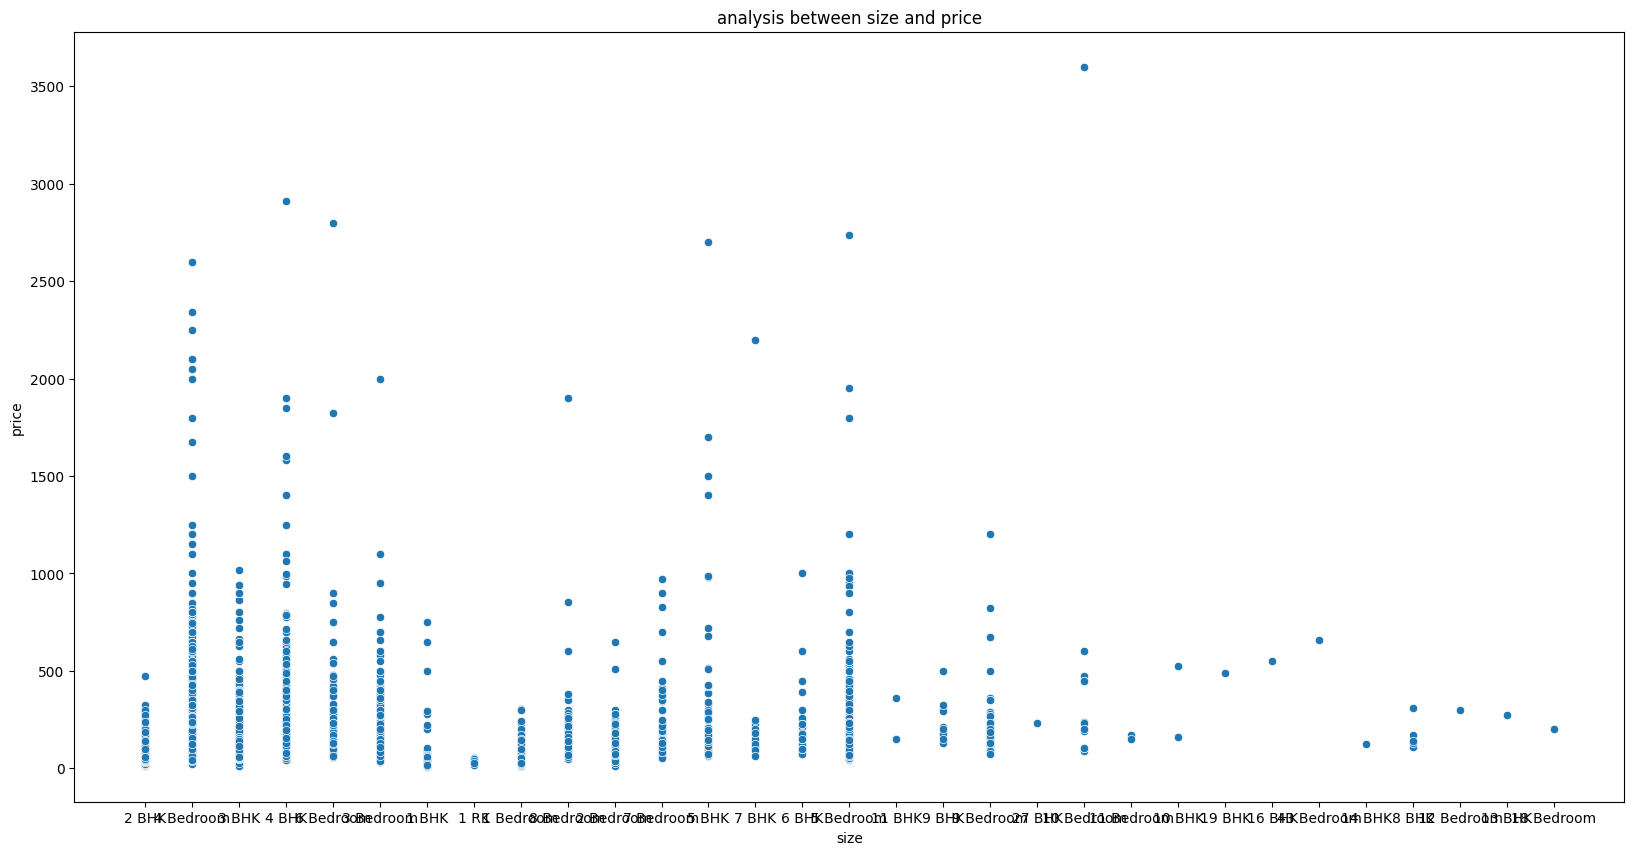

In [125]:
# Plotting a bivaraite analysis between 'size' and 'price'
sns.scatterplot(x='size', y='price', data=data_3)
plt.title('analysis between size and price')
plt.xlabel('size')
plt.ylabel('price')
plt.show()

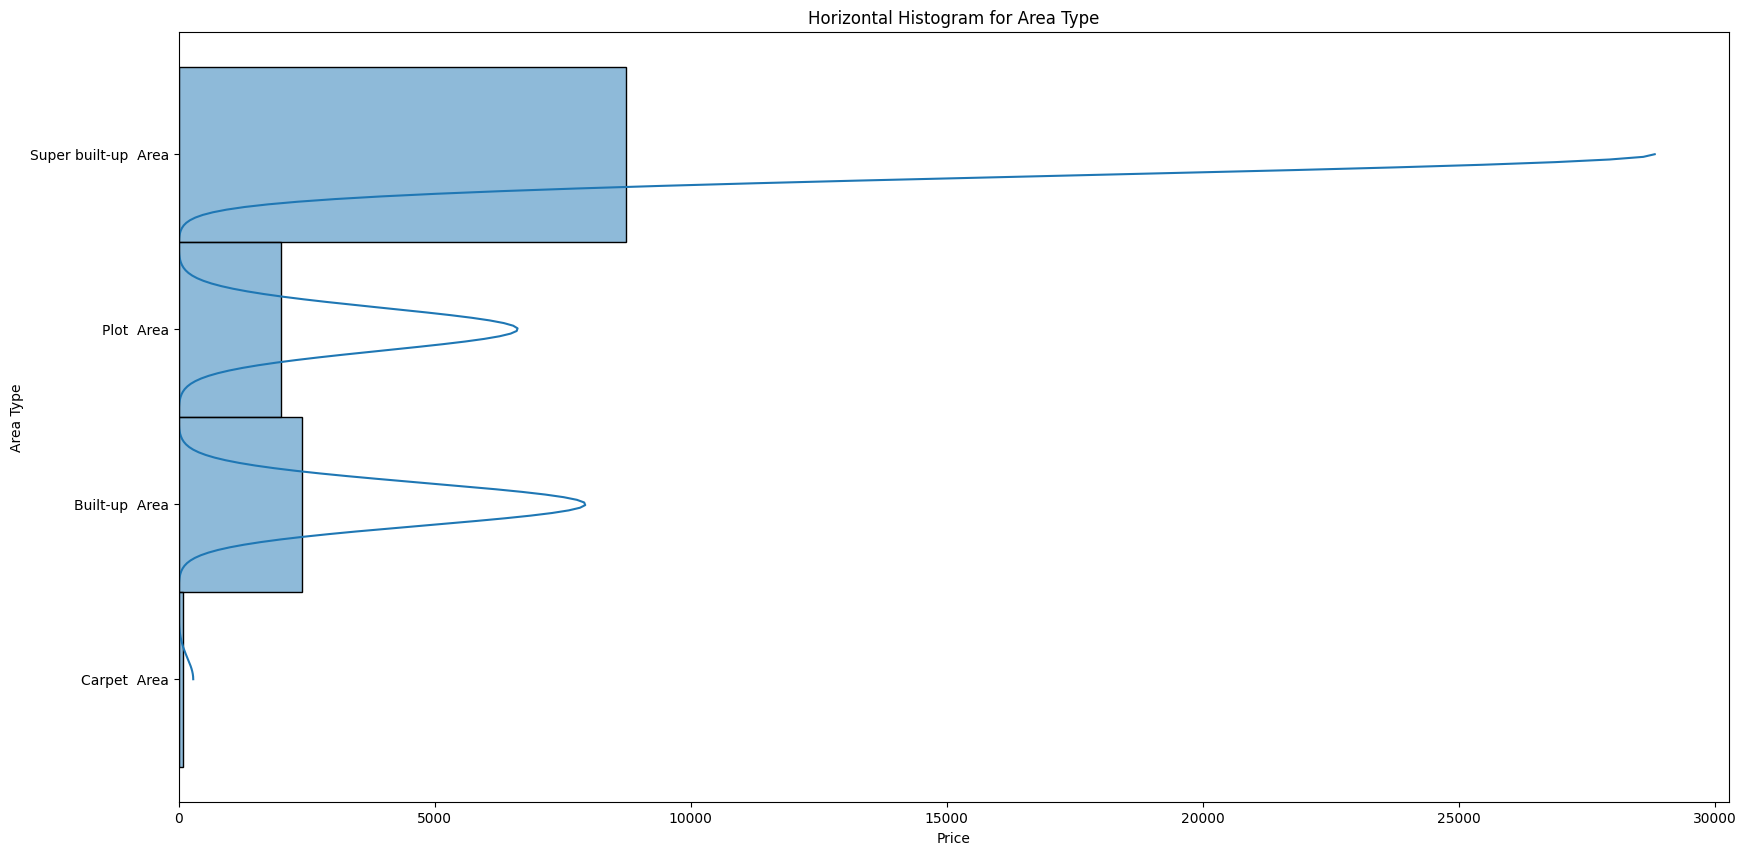

In [126]:
# Plot a horizontal histogram for each area_type
sns.histplot(data=data_3, y='area_type', kde=True)
plt.title('Horizontal Histogram for Area Type')
plt.xlabel('Price')
plt.ylabel('Area Type')
plt.show()

In [127]:
data_4 = data_3.copy()
data_4.head(200)

,area_type,location,size,total_sqft,bath,price,BHK
0,Super built-up Area,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4.0
2,Built-up Area,Uttarahalli,3 BHK,1440.0,2.0,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3.0
4,Super built-up Area,Kothanur,2 BHK,1200.0,2.0,51.00,2.0
...,...,...,...,...,...,...,...
197,Built-up Area,MS Pallya,3 Bedroom,1783.0,3.0,115.00,3.0
198,Super built-up Area,HSR Layout,3 BHK,1400.0,3.0,56.00,3.0
199,Super built-up Area,Nagasandra,2 BHK,980.0,2.0,48.00,2.0
200,Super built-up Area,EPIP Zone,2 BHK,1285.0,2.0,82.00,2.0


In [128]:
data_4.shape

(13246, 7)

In [129]:
data_4.location.unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], shape=(1304,), dtype=object)

In [130]:
# convert location column with more than 10 occurences to 'other'
location_counts = data_4['location'].value_counts()
locations_to_other = location_counts[location_counts <= 10].index
data_4['location'] = data_4['location'].apply(lambda x: 'other' if x in locations_to_other else x)
data_4.head(10)

,area_type,location,size,total_sqft,bath,price,BHK
0,Super built-up Area,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4.0
2,Built-up Area,Uttarahalli,3 BHK,1440.0,2.0,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3.0
4,Super built-up Area,Kothanur,2 BHK,1200.0,2.0,51.00,2.0
5,Super built-up Area,Whitefield,2 BHK,1170.0,2.0,38.00,2.0
6,Super built-up Area,Old Airport Road,4 BHK,2732.0,4.0,204.00,4.0
7,Super built-up Area,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4.0
8,Super built-up Area,Marathahalli,3 BHK,1310.0,3.0,63.25,3.0
9,Plot Area,other,6 Bedroom,1020.0,6.0,370.00,6.0


In [131]:
# create a new column 'price_per_sqft'
data_4['price_per_sqft'] = data_4['price'] * 100000 / data_4['total_sqft']
data_4.head()

,area_type,location,size,total_sqft,bath,price,BHK,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2.0,3699.810606
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4.0,4615.384615
2,Built-up Area,Uttarahalli,3 BHK,1440.0,2.0,62.00,3.0,4305.555556
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3.0,6245.890861
4,Super built-up Area,Kothanur,2 BHK,1200.0,2.0,51.00,2.0,4250.000000


In [132]:
data_4.location.shape

(13246,)

In [133]:
data_5 = data_4.copy()

In [134]:
# Outlier removal 
data_5[data_5.total_sqft/data_5.BHK < 300].head()

,area_type,location,size,total_sqft,bath,price,BHK,price_per_sqft
9,Plot Area,other,6 Bedroom,1020.0,6.0,370.0,6.0,36274.509804
45,Plot Area,HSR Layout,8 Bedroom,600.0,9.0,200.0,8.0,33333.333333
58,Plot Area,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6.0,10660.980810
68,Plot Area,other,8 Bedroom,1350.0,7.0,85.0,8.0,6296.296296
70,Plot Area,other,3 Bedroom,500.0,3.0,100.0,3.0,20000.000000


In [135]:
data_5.shape

(13246, 8)

In [136]:
data_6 = data_5[~(data_5.total_sqft/data_5.BHK < 300)]
data_6.shape

(12502, 8)

In [137]:
data_6.price_per_sqft.describe()

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [138]:
# Remove outliers in 'price_per_sqft' column using mean and standard deviation
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out
data_7 = remove_pps_outliers(data_6)

In [139]:
data_7.shape

(10244, 8)

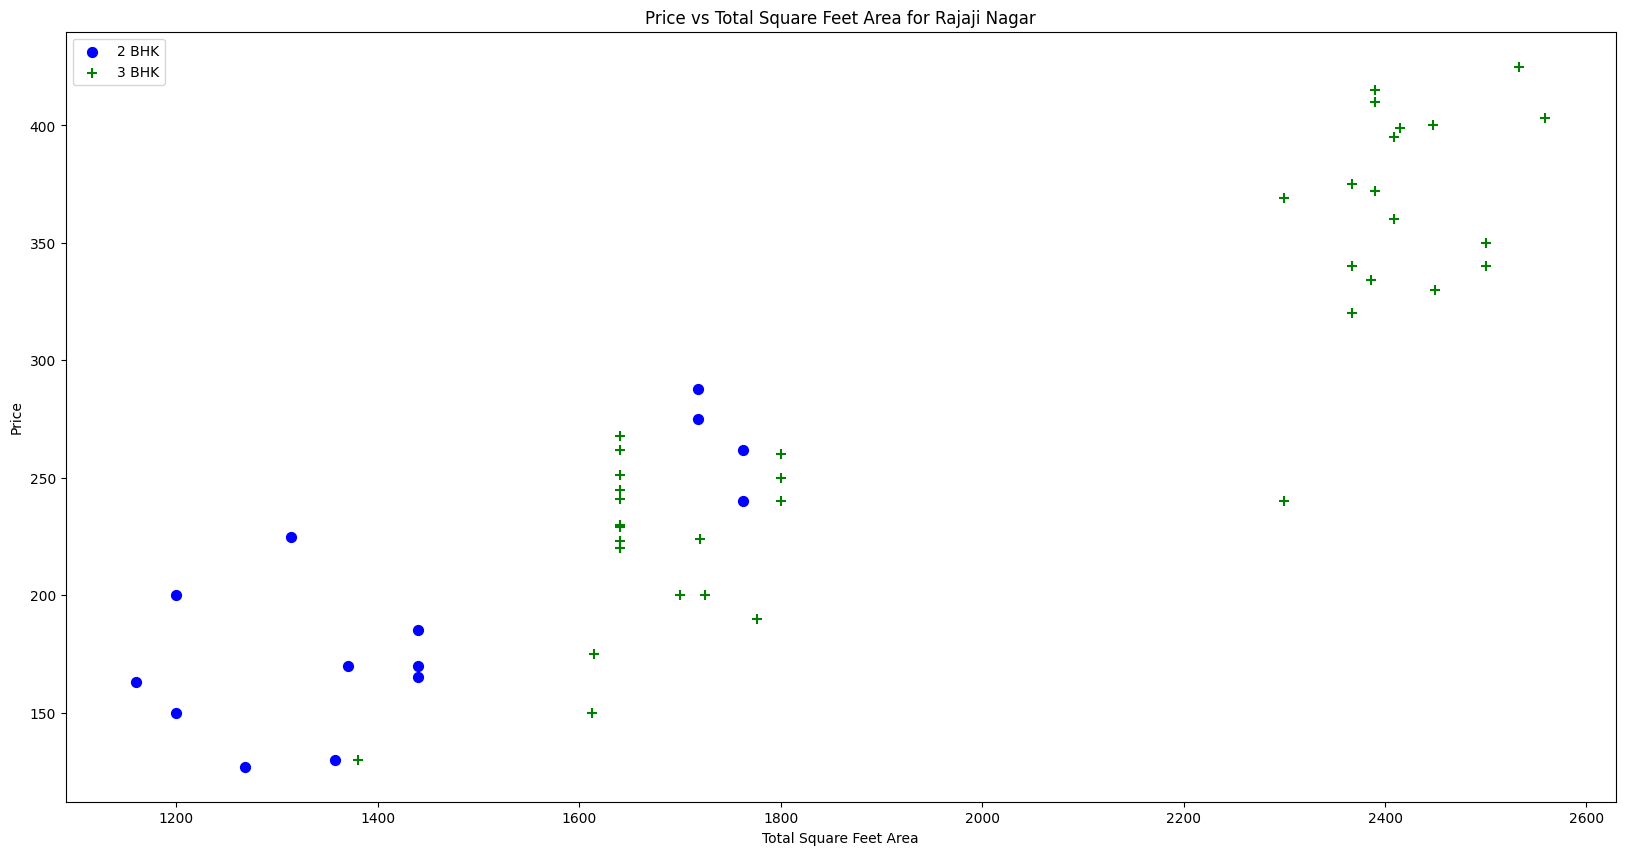

In [140]:
# plot a scatter plot for location in the data set with 2 BHK and 3 BHK
def plot_scatter_chart(df, location):
    bhk2 = df[(df.location == location) & (df.BHK == 2)]
    bhk3 = df[(df.location == location) & (df.BHK == 3)]
    plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft, bhk3.price, color='green', marker='+', label='3 BHK', s=50)
    plt.xlabel('Total Square Feet Area')
    plt.ylabel('Price')
    plt.title(f'Price vs Total Square Feet Area for {location}')
    plt.legend()
    plt.show()

plot_scatter_chart(data_7, 'Rajaji Nagar')

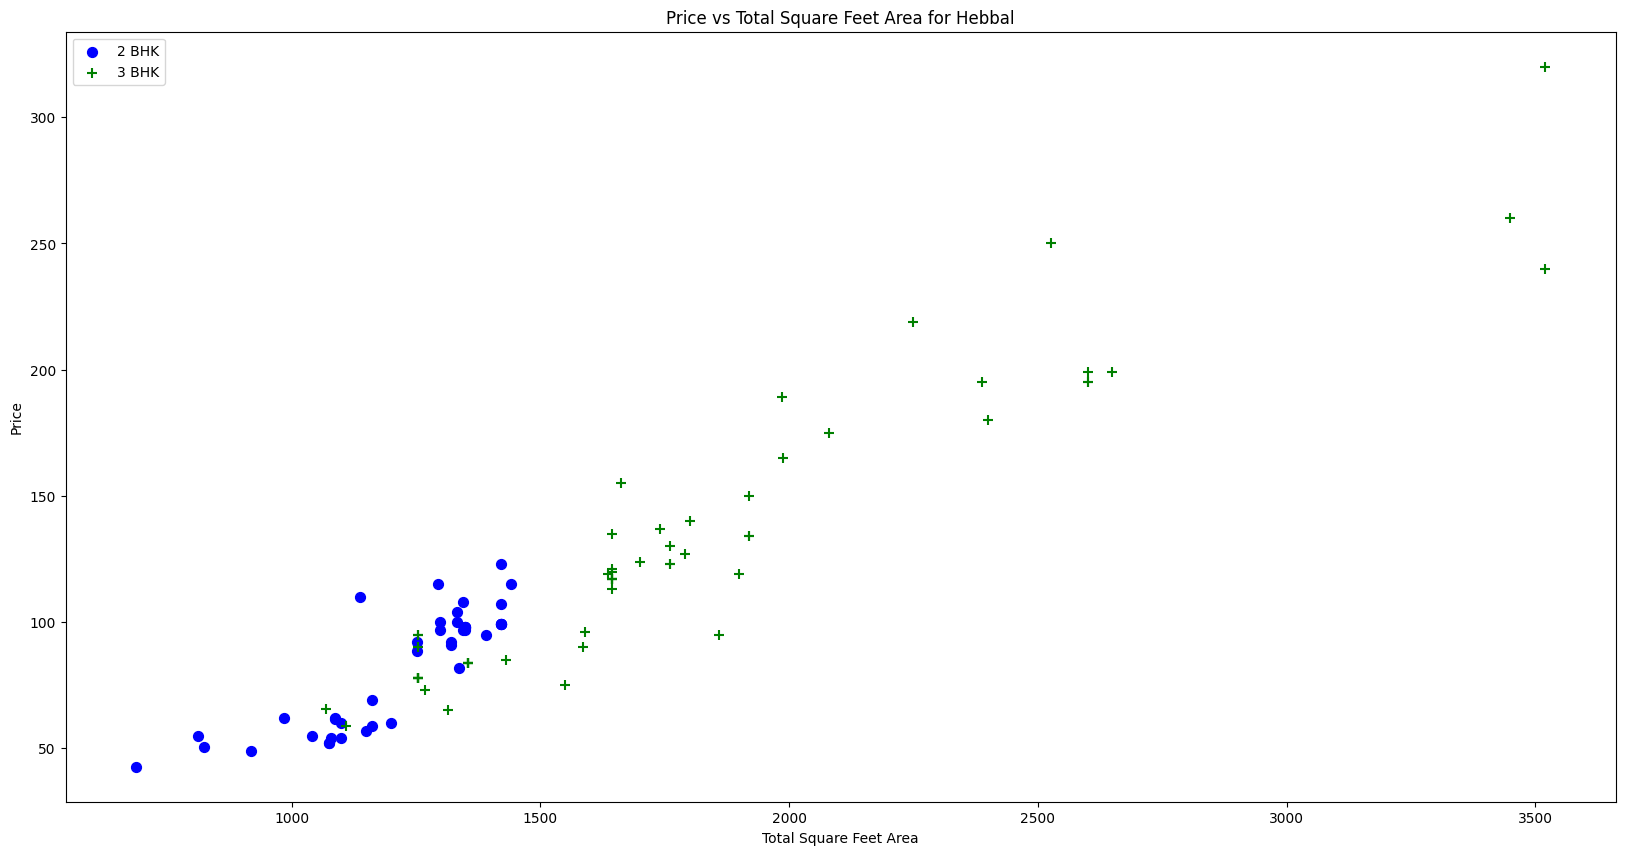

In [141]:
# plot a scatter plot for location in the data set with 2 BHK and 3 BHK
def plot_scatter_chart(df, location):
    bhk2 = df[(df.location == location) & (df.BHK == 2)]
    bhk3 = df[(df.location == location) & (df.BHK == 3)]
    plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft, bhk3.price, color='green', marker='+', label='3 BHK', s=50)
    plt.xlabel('Total Square Feet Area')
    plt.ylabel('Price')
    plt.title(f'Price vs Total Square Feet Area for {location}')
    plt.legend()
    plt.show()

plot_scatter_chart(data_7, 'Hebbal')

We should also remove properties from the same location, the price of[for example]3 bedroom apartment is less than 2 bedroom apartment (with the same square feet area) What we will do is for a given location. we will build a dictionary of stats per BHK

{ 
    '1'  : {
          'mean' : 4000,
          'std' : 2000,
           'count' : 34
    },
    '2'  : {
          'mean' : 4300
          'std' : 2300
          'count' : 22
    },
}

Now we can remove those 2BHK apartment whose price_per_sqft is less than mean price_per_sqft of 1 BHK apartment

In [142]:
# define a function that removes outliers in BHK and groups by location
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('BHK'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('BHK'):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df.price_per_sqft < (stats['mean'])].index.values
                )
    return df.drop(exclude_indices, axis='index')

data_8 = remove_bhk_outliers(data_7)
data_8.shape

(7342, 8)

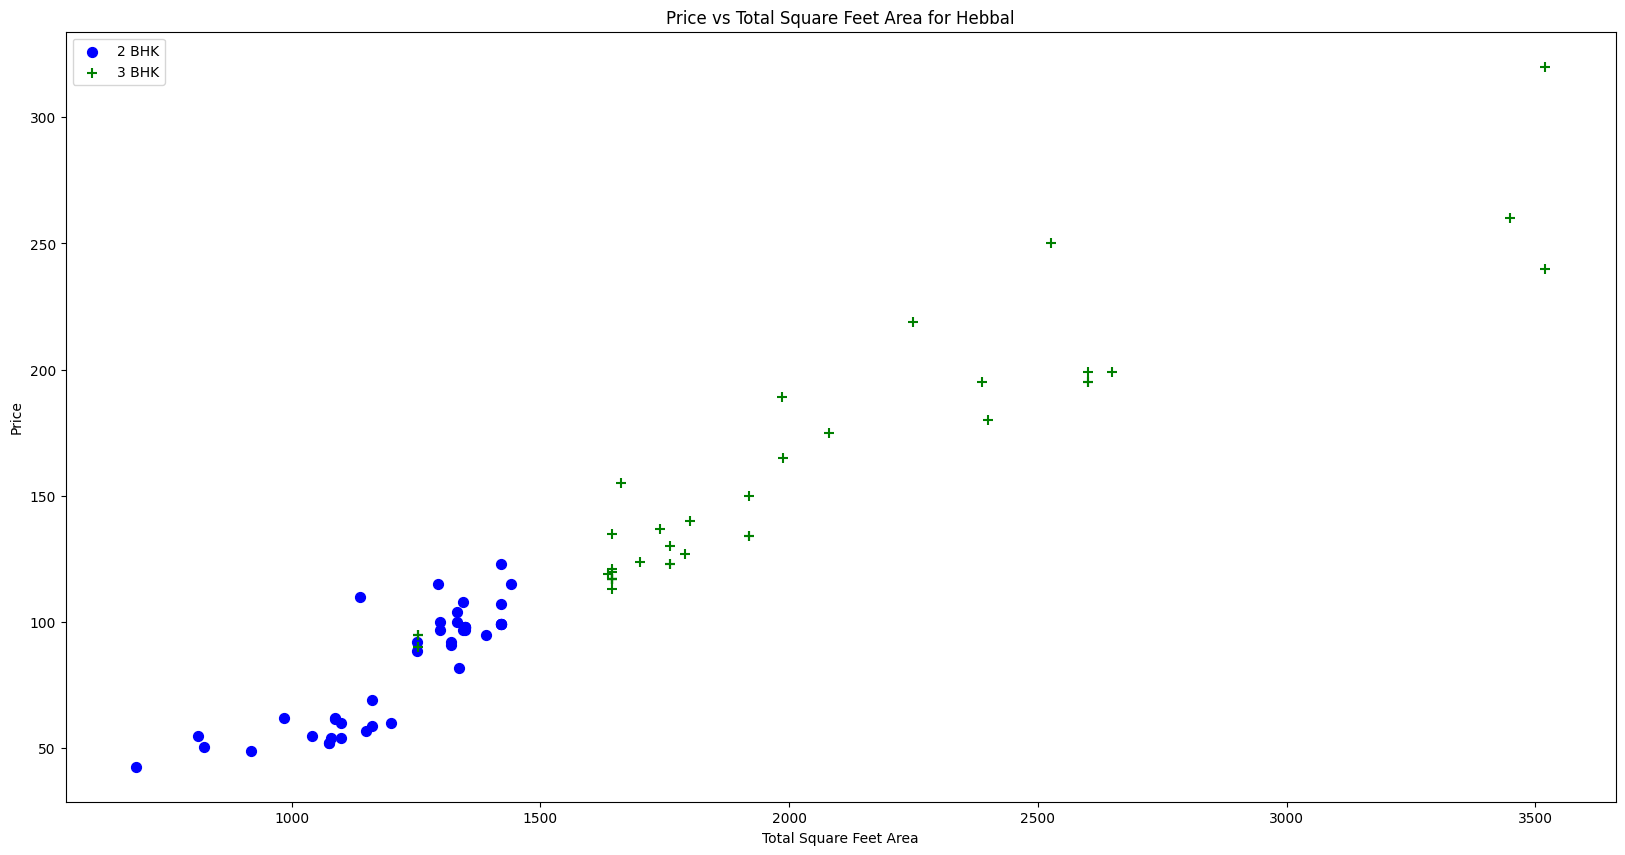

In [143]:
# plot a scatter plot for location in the data set with 2 BHK and 3 BHK
def plot_scatter_chart(df, location):
    bhk2 = df[(df.location == location) & (df.BHK == 2)]
    bhk3 = df[(df.location == location) & (df.BHK == 3)]
    plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft, bhk3.price, color='green', marker='+', label='3 BHK', s=50)
    plt.xlabel('Total Square Feet Area')
    plt.ylabel('Price')
    plt.title(f'Price vs Total Square Feet Area for {location}')
    plt.legend()
    plt.show()

plot_scatter_chart(data_8, 'Hebbal')

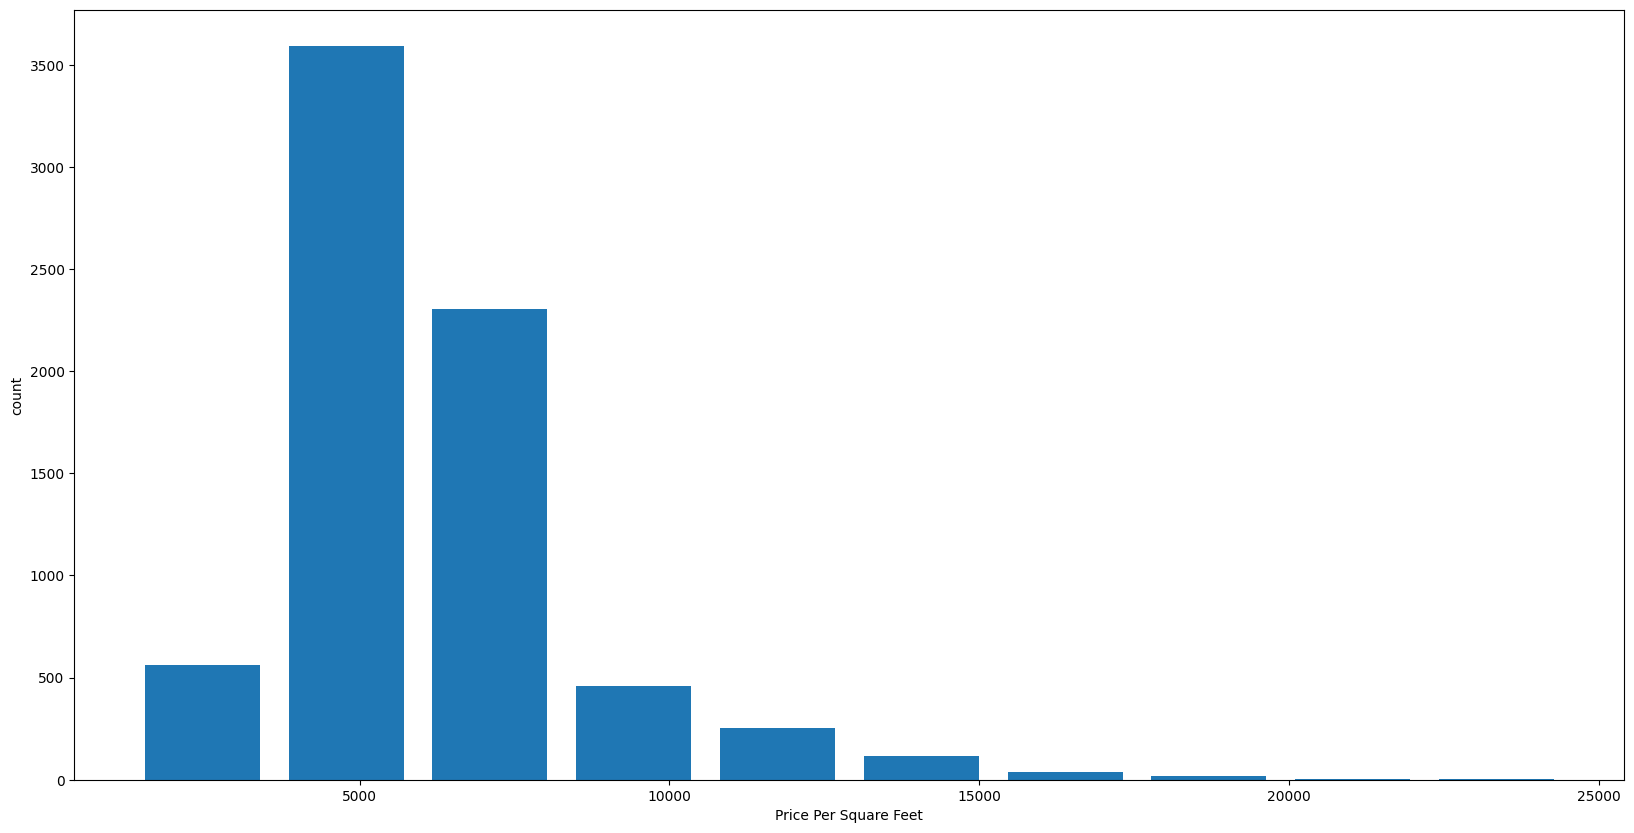

In [144]:
# plot a histrogram to see price_per_sqft distribution
import matplotlib 
matplotlib.rcParams['figure.figsize'] = (20,10)
plt.hist(data_8.price_per_sqft, rwidth=0.8)
plt.xlabel('Price Per Square Feet')
plt.ylabel('count')
plt.show()

Exploring the bathroom features

In [145]:
data_8.bath.unique()

array([ 2.,  3.,  4.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

In [146]:
data_8[data_8.bath > 10]

,area_type,location,size,total_sqft,bath,price,BHK,price_per_sqft
5271,Super built-up Area,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10.0,4000.000000
8481,Super built-up Area,other,10 BHK,12000.0,12.0,525.0,10.0,4375.000000
8570,Super built-up Area,other,16 BHK,10000.0,16.0,550.0,16.0,5500.000000
9309,Super built-up Area,other,11 BHK,6000.0,12.0,150.0,11.0,2500.000000
9641,Super built-up Area,other,13 BHK,5425.0,13.0,275.0,13.0,5069.124424


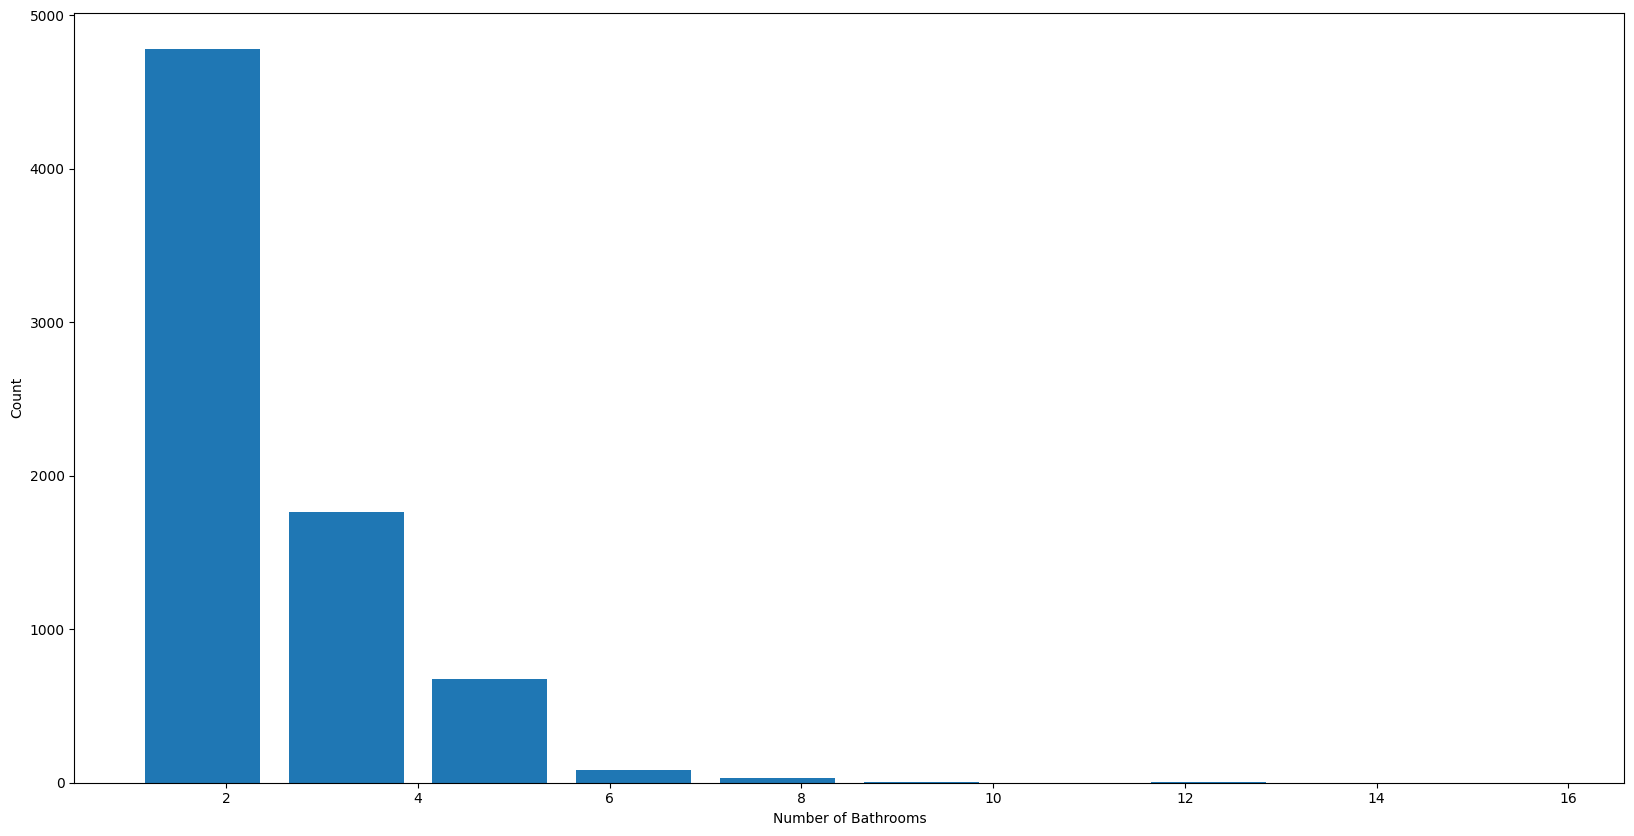

In [147]:
# plot a histogram of bath column
plt.hist(data_8.bath, rwidth=0.8)
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count')
plt.show()

Domain knowlegde lets us understand that 2 more bathrooms after the actual count of bedrooms are outliers 

In [148]:
# Remove bathrooms greater than BHK +2
data_8 = data_8[data_8.bath <= data_8.BHK +2]
data_8.shape

(7338, 8)

In [149]:
# drop unneccessary columns 'area_type', 'size', 'price_per_sqft'
data_9 = data_8.drop(['area_type', 'size', 'price_per_sqft'], axis=1)
data_9.shape

(7338, 5)

In [150]:
data_9.head()

,location,total_sqft,bath,price,BHK
1,Devarachikkanahalli,1250.0,2.0,40.0,2.0
2,Devarachikkanahalli,1200.0,2.0,83.0,2.0
3,Devarachikkanahalli,1170.0,2.0,40.0,2.0
4,Devarachikkanahalli,1425.0,2.0,65.0,3.0
5,Devarachikkanahalli,947.0,2.0,43.0,2.0


At this stage we begin to build a model, but first we need to turn location into boolean which a machine learning can understand

In [152]:
# Get dummy variable for location column
dummies = pd.get_dummies(data_9.location)
dummies.head()

,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [153]:
# concatinate data_9 and dummies dataframes
data_10 = pd.concat([data_9, dummies.drop('other', axis=1)], axis=1)
data_10.head()

,location,total_sqft,bath,price,BHK,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
1,Devarachikkanahalli,1250.0,2.0,40.0,2.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Devarachikkanahalli,1200.0,2.0,83.0,2.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Devarachikkanahalli,1170.0,2.0,40.0,2.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Devarachikkanahalli,1425.0,2.0,65.0,3.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,Devarachikkanahalli,947.0,2.0,43.0,2.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [154]:
# Drop location column from data_9
data_10 = data_10.drop('location', axis=1)
data_10.head()

,total_sqft,bath,price,BHK,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
1,1250.0,2.0,40.0,2.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1200.0,2.0,83.0,2.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1170.0,2.0,40.0,2.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1425.0,2.0,65.0,3.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,947.0,2.0,43.0,2.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [155]:
data_11 = data_10.copy()
data_11.head()

,total_sqft,bath,price,BHK,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
1,1250.0,2.0,40.0,2.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1200.0,2.0,83.0,2.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1170.0,2.0,40.0,2.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1425.0,2.0,65.0,3.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,947.0,2.0,43.0,2.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [156]:
data_11.shape

(7338, 245)

In [158]:
X = data_11.drop('price', axis=1)
X.head()

,total_sqft,bath,BHK,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
1,1250.0,2.0,2.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1200.0,2.0,2.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1170.0,2.0,2.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1425.0,2.0,3.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,947.0,2.0,2.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [159]:
y = data_11['price']
y.head()

1    40.0
2    83.0
3    40.0
4    65.0
5    43.0
Name: price, dtype: float64

In [160]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)


In [161]:
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(X_train, y_train)
lr_clf.score(X_test, y_test)


0.8392267401375412

Using a careful cross validation 

In [162]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.81104968, 0.8374246 , 0.84924769, 0.81449485, 0.79792368])

In [165]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

def find_the_best_model_using_GridSearchCV(X, y):
    algos = {
        'linear_regression': {
            'model': LinearRegression(),
            'params': {
                # 'normalize' is removed in recent scikit-learn versions; use fit_intercept instead
                'fit_intercept': [True, False]
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [0.1, 0.5, 1.0],
                'selection': ['cyclic', 'random']
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                # use the modern name for mean squared error
                'criterion': ['squared_error', 'friedman_mse'],
                'splitter': ['best', 'random']
            }
        }
    }
    
    scores = []
    # reuse the existing ShuffleSplit `cv` defined earlier in the notebook if available
    cv_used = cv if 'cv' in globals() else 5
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv=cv_used, return_train_score=False)
        gs.fit(X, y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })
    
    return pd.DataFrame(scores)

find_the_best_model_using_GridSearchCV(X, y)

,model,best_score,best_params
0,linear_regression,0.822279,{'fit_intercept': False}
1,lasso,0.776956,"{'alpha': 0.1, 'selection': 'cyclic'}"
2,decision_tree,0.721023,"{'criterion': 'squared_error', 'splitter': 'ra..."


In [166]:
X.columns

Index(['total_sqft', 'bath', 'BHK', ' Devarachikkanahalli',
       '1st Block Jayanagar', '1st Phase JP Nagar',
       '2nd Phase Judicial Layout', '2nd Stage Nagarbhavi',
       '5th Block Hbr Layout', '5th Phase JP Nagar',
       ...
       'Vijayanagar', 'Vishveshwarya Layout', 'Vishwapriya Layout',
       'Vittasandra', 'Whitefield', 'Yelachenahalli', 'Yelahanka',
       'Yelahanka New Town', 'Yelenahalli', 'Yeshwanthpur'],
      dtype='object', length=244)

In [169]:
# how many times does '2nd Phase Judicial Layout' appear in location column
(data_11['2nd Phase Judicial Layout'] == 1).sum()

np.int64(8)

In [171]:
def predict_price(location, sqft, bath, bhk):
    loc_index = np.where(X.columns == location)[0][0]


    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    if loc_index >= 0:
        x[loc_index] = 1
    
    return lr_clf.predict([x])[0]

In [172]:
predict_price('1st Phase JP Nagar', 1000, 2, 2)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(84.80096614028345)

In [173]:
predict_price('1st Phase JP Nagar', 1000, 3, 3)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(88.29120005839344)

In [174]:
predict_price('Indira Nagar', 1000, 2, 2)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(175.06182706819715)

In [175]:
predict_price('Indira Nagar', 1000, 3, 3)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(178.5520609863072)

In [176]:
import pickle
with open('bangalore_home_price_model.pickle', 'wb') as f:
    pickle.dump(lr_clf, f)

In [177]:
import json
columns = {
    'data_columns' : [col for col in X.columns]
}
with open("columns.json", "w") as f:
    json.dump(columns, f)